In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [7]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
mode = 'SyntheticBanding'
model_dir = "D:/DeepSSFP/"
model_name="knee_study"

100%|██████████| 4/4 [00:08<00:00,  2.20s/it]


Dataset loaded: (2560, 416, 416, 8)
Memory size: 7.08837376 GB
Dataset shape: (2560, 416, 416, 8)
Formatting data for SyntheticBanding mode...
Data format complete.
Input shape: (2560, 416, 416, 4), Output shape: (2560, 416, 416, 4)
Selected indices: [1335 2042]
Figure size: (8, 4)


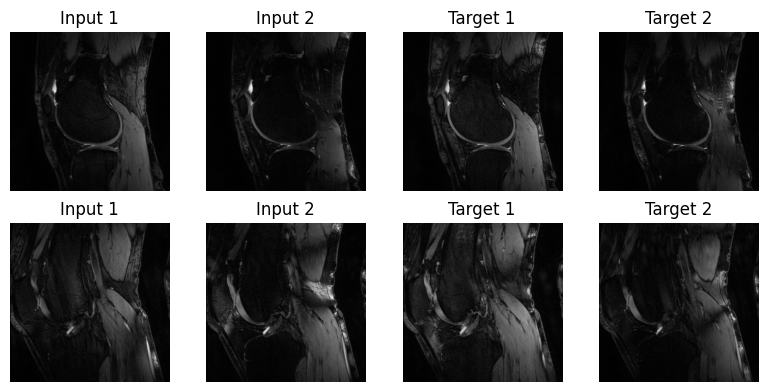

In [ ]:
import deepssfp.dataloader
import deepssfp.dataformatter

path = 'D:/MRI/2024_Krithika_KneeStudy'

filters = [
    'HV1_lk_r1', 'HV2_lk_r1', 'HV3_lk_r1', 'HV4_lk_r1', 'HV5_lk_r1', 'HV6_lk_r1', 'HV7_lk_r1', 'HV8_lk_r1',
    'HV1_lk_r2', 'HV2_lk_r2', 'HV3_lk_r2', 'HV4_lk_r2', 'HV5_lk_r2', 'HV6_lk_r2', 'HV7_lk_r2', 'HV8_lk_r2',
    'HV1_rk_r1', 'HV2_rk_r1', 'HV3_rk_r1', 'HV4_rk_r1', 'HV5_rk_r1', 'HV6_rk_r1', 'HV7_rk_r1', 'HV8_rk_r1',
    'HV1_rk_r2', 'HV2_rk_r2', 'HV3_rk_r2', 'HV4_rk_r2', 'HV5_rk_r2', 'HV6_rk_r2', 'HV7_rk_r2', 'HV8_rk_r2']

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters, data_format='RealImag')
print(f"Dataset shape: {dataset['M'].shape}")
input, output = deepssfp.dataformatter.format_synthetic_banding_for_realimag_data(dataset['M'])
print(f"Input shape: {input.shape}, Output shape: {output.shape}")

deepssfp.visualize_images(
    input_images=input,
    target_images=output,
    num_samples=2,
)

Info: Data all ready formated.
Dataset: mode:SyntheticBanding, size:2560 height:416 width:416 cin:4 cout:4 ratio:0.8
dtype: float16, float16
Using same scaler for SyntheticBanding mode
Training DataSet: (2048, 416, 416, 4) | (2048, 416, 416, 4)
Test DataSet: (512, 416, 416, 4) | (512, 416, 416, 4)
Selected indices: [166  48]
Figure size: (8, 4)


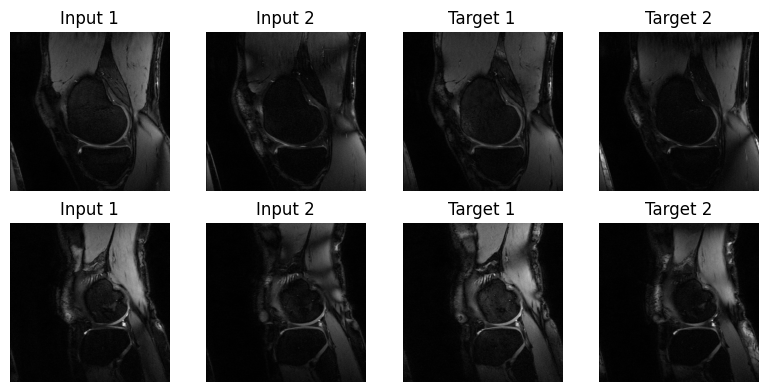

In [4]:
del dataset
ds = deepssfp.dataset.Dataset('SyntheticBanding', input_data=input, output_data=output, stats_fraction=0.1)

del input
del output

print(f"Training DataSet: {ds.x_train.shape} | {ds.y_train.shape}")
print(f"Test DataSet: {ds.x_test.shape} | {ds.y_test.shape}")

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=2,
)


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/knee_study_syntheticbanding
Dataset path: D:/DeepSSFP/knee_study_dataset.npy
Info: dataset (ds) already loaded.
Training data shape: (2048, 416, 416, 4), (2048, 416, 416, 4)
Input scaler stats: mean=-0.0398, std=25.3446
Output scaler stats: mean=-0.0398, std=25.3446
Selected indices: [462 121  83]
Figure size: (8, 6)


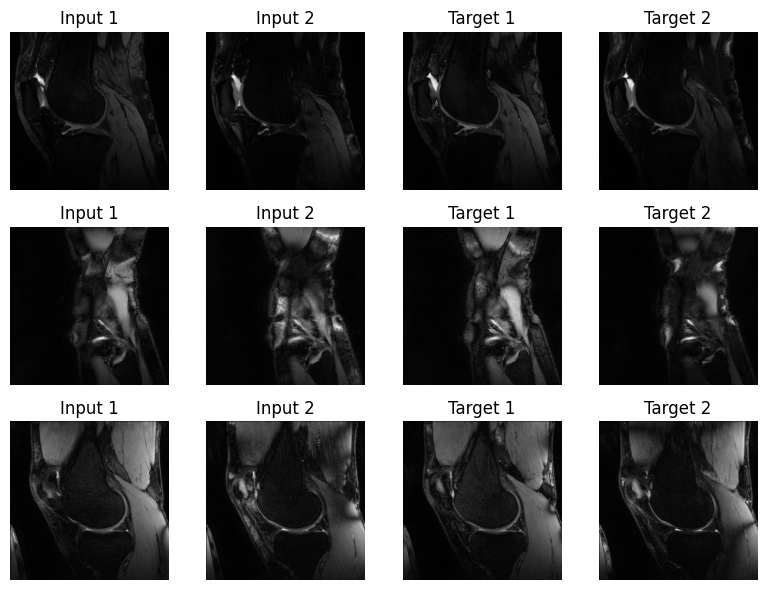

2025-04-08 10:30:51,063 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/knee_study_syntheticbanding
2025-04-08 10:30:51,063 - DeepSSFP - INFO - Training DataSet: (2048, 416, 416, 4) | (2048, 416, 416, 4)
2025-04-08 10:30:51,064 - DeepSSFP - INFO - Test DataSet: (512, 416, 416, 4) | (512, 416, 416, 4)
2025-04-08 10:30:51,066 - DeepSSFP - INFO - Creating new model with dimensions: 416x416x4→4
2025-04-08 10:30:51,256 - DeepSSFP - INFO - Model created: unet



Training model...
Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 416, 416, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 416, 416, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 416, 416, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 416, 416, 32) 128         conv2d_1[0][0]                   
____________________________________________________________________________

2025-04-08 11:59:51,424 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/knee_study_syntheticbanding.keras


16/16 [==============================] - 3s 181ms/step - loss: 0.1615 - mean_absolute_error: 0.2420


2025-04-08 12:00:00,116 - DeepSSFP - INFO - Training Complete. Loss: 0.1615, MAE: 0.2420
2025-04-08 12:00:00,117 - DeepSSFP - INFO - Time Elapsed: 5348.85 seconds
2025-04-08 12:00:01,866 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_training_history.png


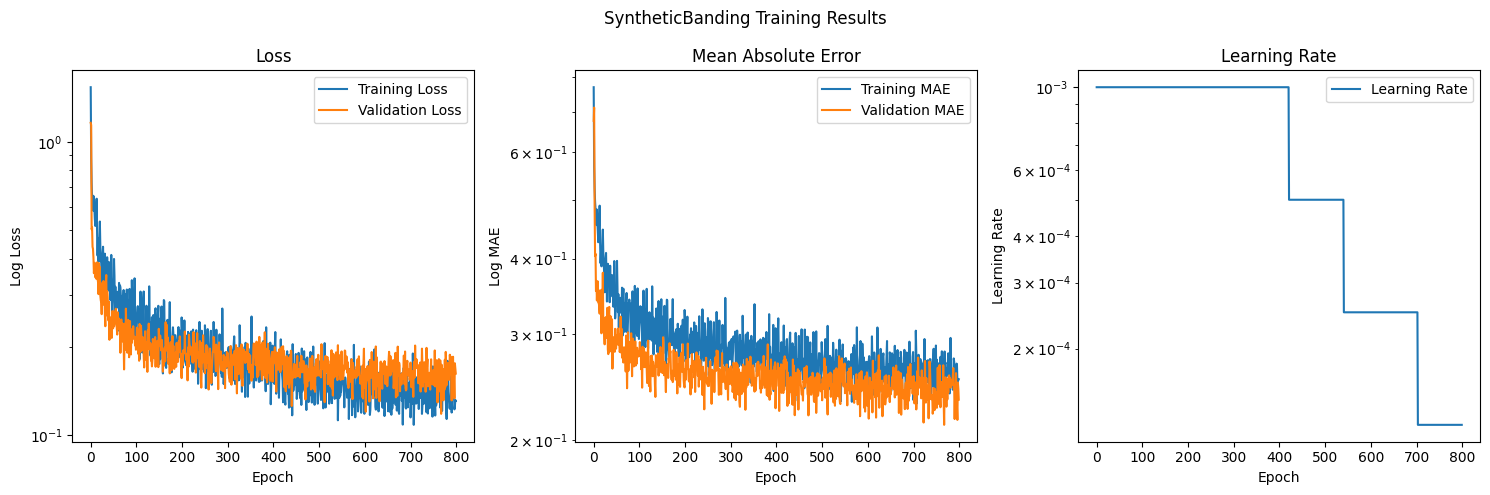

In [6]:
import deepssfp.analysis
results = deepssfp.analysis.run_training(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    ds=ds,
    #custom_dataset=dataset,
    save_dataset=False,
)

Selected indices: [495 159]
Figure size: (12, 4)


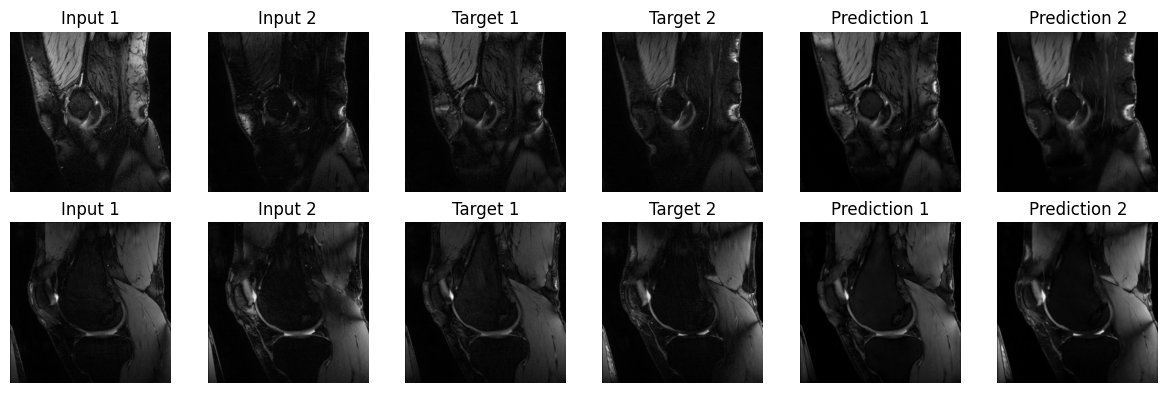

In [ ]:
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")

# Generate predictions
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.outputScaler.inverse_transform(deepssfp.predict(results['model'], ds.x_test))

# Visualize results
deepssfp.visualize_images(
    input_images=x_test,
    target_images=y_test,
    predicted_images=predictions,
    num_samples=2,
    save_path=f"{path}_prediction_results.png"
)


In [ ]:
test_path = save_path=f"{path}_test_predictions"
np.save(test_path, [{'input':x_test, 'target':y_test, 'prediction':predictions}])

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt

def compare_images(target, estimated):
    """
    Calculate various metrics to compare target and estimated images.
    
    Parameters:
    -----------
    target : numpy.ndarray
        The ground truth or target 2D image
    estimated : numpy.ndarray
        The estimated or predicted 2D image
    
    Returns:
    --------
    dict
        Dictionary containing comparison metrics
    """
    # Ensure both images have the same shape
    if target.shape != estimated.shape:
        raise ValueError(f"Images must have the same shape. Got {target.shape} and {estimated.shape}")
    
    # Calculate pixel-wise difference
    diff = target - estimated
    
    # Basic statistics of the difference
    metrics = {
        'mean_error': np.mean(diff),
        'mean_absolute_error': np.mean(np.abs(diff)),
        'mean_squared_error': np.mean(np.square(diff)),
        'root_mean_squared_error': np.sqrt(np.mean(np.square(diff))),
        'max_error': np.max(np.abs(diff)),
        'min_error': np.min(np.abs(diff)),
        'std_error': np.std(diff),
    }
    
    # Calculate normalized metrics (if images are not binary)
    if np.max(target) > 1 or np.max(estimated) > 1:
        # Assume images are in range [0, 255]
        max_val = 255.0
    else:
        # Assume images are normalized in range [0, 1]
        max_val = 1.0
    
    # Calculate PSNR (Peak Signal-to-Noise Ratio)
    # Higher is better, typical values are between 20 and 40
    metrics['psnr'] = psnr(target, estimated, data_range=max_val)
    
    # Calculate SSIM (Structural Similarity Index)
    # Ranges from -1 to 1, where 1 means perfect similarity
    metrics['ssim'] = ssim(target, estimated, data_range=max_val)
    
    # Calculate correlation coefficient
    # Ranges from -1 to 1, where 1 means perfect correlation
    if np.std(target) > 0 and np.std(estimated) > 0:  # Avoid division by zero
        metrics['correlation'] = np.corrcoef(target.flatten(), estimated.flatten())[0, 1]
    else:
        metrics['correlation'] = np.nan
    
    return metrics

def visualize_comparison(target, estimated, title=None):
    """
    Visualize the target, estimated, and difference images.
    
    Parameters:
    -----------
    target : numpy.ndarray
        The ground truth or target 2D image
    estimated : numpy.ndarray
        The estimated or predicted 2D image
    title : str, optional
        Title for the plot
    """
    diff = target - estimated
    abs_diff = np.abs(diff)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Target image
    im0 = axes[0, 0].imshow(target, cmap='viridis')
    axes[0, 0].set_title('Target Image')
    plt.colorbar(im0, ax=axes[0, 0])
    
    # Estimated image
    im1 = axes[0, 1].imshow(estimated, cmap='viridis')
    axes[0, 1].set_title('Estimated Image')
    plt.colorbar(im1, ax=axes[0, 1])
    
    # Difference image
    im2 = axes[1, 0].imshow(diff, cmap='RdBu_r')
    axes[1, 0].set_title('Difference (Target - Estimated)')
    plt.colorbar(im2, ax=axes[1, 0])
    
    # Absolute difference image
    im3 = axes[1, 1].imshow(abs_diff, cmap='hot')
    axes[1, 1].set_title('Absolute Difference')
    plt.colorbar(im3, ax=axes[1, 1])
    
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.tight_layout()
    return fig

# Example usage:
"""
# Creating sample data
target = np.random.rand(100, 100)
estimated = target + 0.1 * np.random.randn(100, 100)  # Add some noise

# Calculate metrics
metrics = compare_images(target, estimated)
for metric, value in metrics.items():
    print(f"{metric}: {value}")

# Visualize the comparison
fig = visualize_comparison(target, estimated, "Comparison of Target and Estimated Images")
plt.show()
"""

'\n# Creating sample data\ntarget = np.random.rand(100, 100)\nestimated = target + 0.1 * np.random.randn(100, 100)  # Add some noise\n\n# Calculate metrics\nmetrics = compare_images(target, estimated)\nfor metric, value in metrics.items():\n    print(f"{metric}: {value}")\n\n# Visualize the comparison\nfig = visualize_comparison(target, estimated, "Comparison of Target and Estimated Images")\nplt.show()\n'

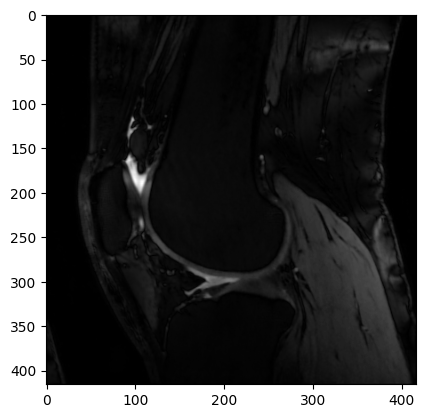

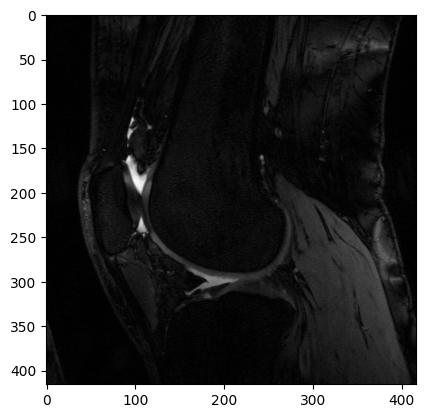

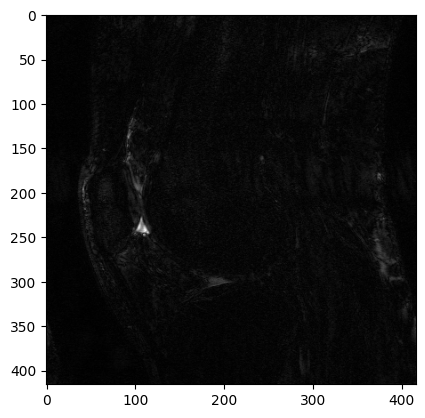

mean_error: 4.7245919438582105
mean_absolute_error: 7.04328995208979
mean_squared_error: 118.14169506373878
root_mean_squared_error: 10.869300578406081
max_error: 270.07617336697956
min_error: 2.483953742249412e-06
std_error: 9.788765296387941
psnr: 27.406771631666402
ssim: 0.6735107028685484
correlation: 0.9579540575043853


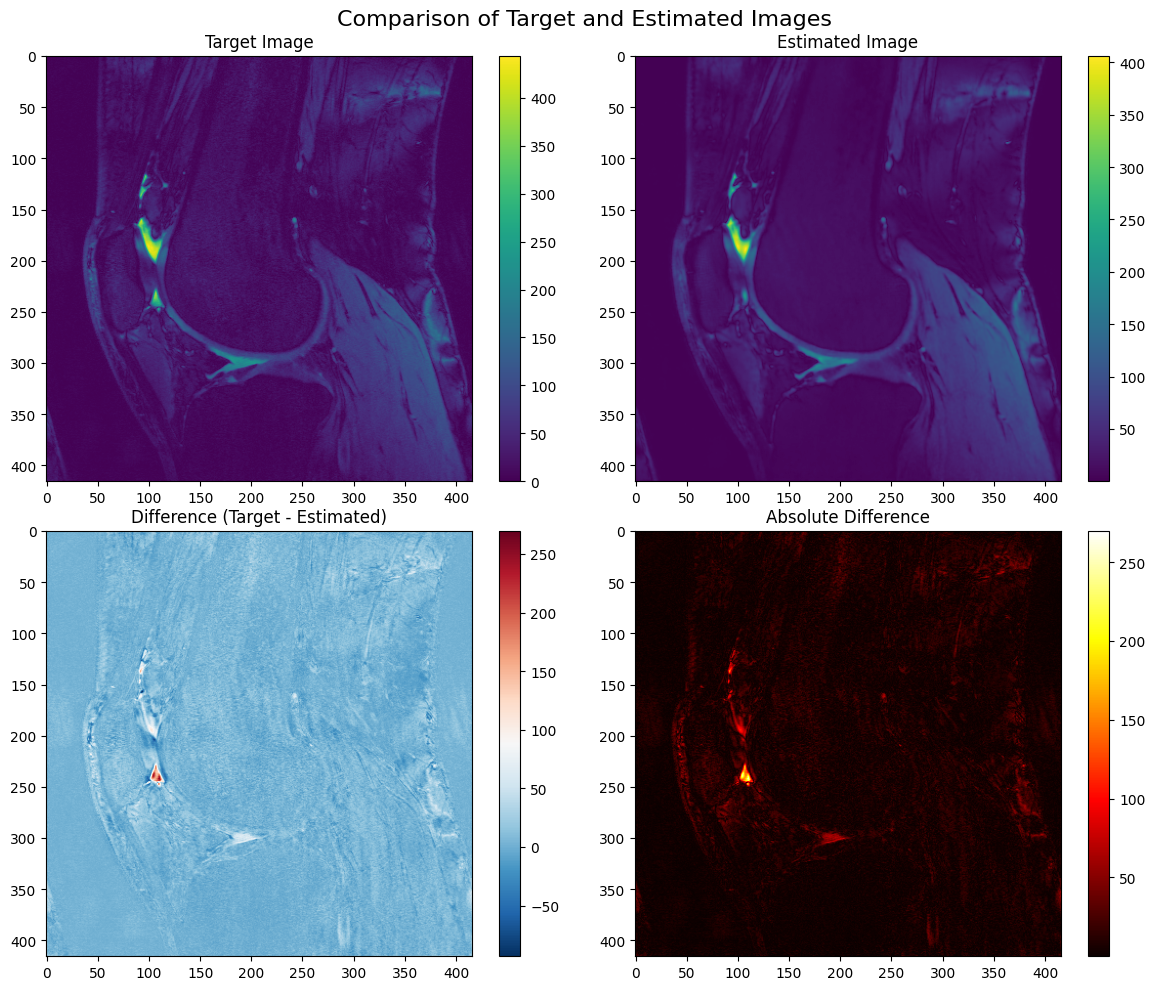

In [21]:
pred_complex = deepssfp.from_pairs_to_complex(predictions)
target_complex = deepssfp.from_pairs_to_complex(y_test)
idx = 242 # 214
plt.imshow(np.abs(pred_complex[idx,:,:,0]), cmap='gray')
plt.show()

plt.imshow(np.abs(target_complex[idx,:,:,0]), cmap='gray')
plt.show()

plt.imshow(np.abs(pred_complex[idx,:,:,0] - target_complex[idx,:,:,0]), cmap='gray')
plt.show()

# Calculate metrics
target = np.abs(target_complex[idx,:,:,0])
estimated = np.abs(pred_complex[idx,:,:,0])
metrics = compare_images(target, estimated)
for metric, value in metrics.items():
    print(f"{metric}: {value}")

# Visualize the comparison
fig = visualize_comparison(target, estimated, "Comparison of Target and Estimated Images")
plt.show()